# Dataquest 2023 Preliminary: outlier imputation, diff/rolling/inverse-diff features and feature selection with CatBoost (submission score 0.71483)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px
from scipy import stats
from tqdm import tqdm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import catboost as cb
import xgboost as xgb
import lightgbm as lgb
from pycaret.regression import *

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

DATA_DIR = "../data"
SUBMISSION_DIR = "../submissions"

## Helper

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## Load Data

In [ ]:
ori_train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
ori_train_df.head()

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
0,283996800,1979-01-01 00:00:00+00:00,28800,24.75 Celcius,NaN,23.89 C,25.76 C,24.28,25.22°C,1012,undetermined,NaN,95,0.82,320.0 °,zero,0,NaN,NaN,100
1,284000400,1979-01-01 01:00:00+00:00,28800,24.58 C,NaN,23.73 C,25.57 C,23.99 C,25.26 C,1012,NaN,NaN,95,0.96 m/s,338.0°,0,0,0,0,100
2,284004000,1979-01-01 02:00:00+00:00,28800,26.6 Celcius,unidentified,24.06 C,26.6 C,26.1 C,27.39,1012,NaN,undetermined,86,1.22 m/s,339.0°,0,volume:zero,NaN,NaN,99
3,284007600,1979-01-01 03:00:00+00:00,28800,27.31 Celcius,NaN,24.37 C,30.9 C,26.59,28.36 C,1012,NaN,undetermined,84,1.08 m/s,342,0.13,nol,0,NaN,94
4,284011200,1979-01-01 04:00:00+00:00,28800,27.41,NaN,25.05 C,31.54 C,26.58 C,28.31 °C,1011,NaN,undetermined,87,0.86,336.0°,0.34,nol,NaN,0,100


## Clean Data

In [ ]:
def clean_cols(df, is_train=True):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')

    # function to clean unit
    def clean_unit(x):
        temp_pattern = r'-?\d+(\.\d+)?'
        regex = re.search(temp_pattern, str(x))
        return float(regex.group(0)) if regex else np.nan

    # clean unit
    df['temp'] = df['temp'].apply(clean_unit)
    df['d_point'] = df['d_point'].apply(clean_unit)
    df['feels'] = df['feels'].apply(clean_unit)
    df['min_temp'] = df['min_temp'].apply(clean_unit)
    df['max_temp'] = df['max_temp'].apply(clean_unit)
    df['prssr'] = df['prssr'].apply(clean_unit)
    df['hum'] = df['hum'].apply(clean_unit)
    df['wind_spd'] = df['wind_spd'].apply(clean_unit)
    df['wind_deg'] = df['wind_deg'].apply(clean_unit)
    df['clouds'] = df['clouds'].apply(clean_unit)

    # df.loc[df['hum'] > 100, 'hum'] = 100

    # clean rain_1h
    if is_train:
        df.loc[df['rain_1h'] == 'zero', 'rain_1h'] = 0
        df.loc[df['rain_1h'] == ' ', 'rain_1h'] = 0
        df['rain_1h'] = df['rain_1h'].apply(clean_unit)
        df.loc[df['rain_1h'] < 0, 'rain_1h'] = 0

    # drop useless columns
    df.drop(['datetime_iso',
             'time-zone',
             'visibility',
             'sea_level',
             'grnd_level',
             'rain_3h',
             'snow_1h',
             'snow_3h'],
            axis=1, inplace=True)

    return df

In [ ]:
train_df = ori_train_df.copy()
train_df = clean_cols(train_df)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0


## Baseline

In [ ]:
X = train_df.drop([
    'rain_1h',
    # 'rain_1h_bool'
], axis=1)
y = train_df['rain_1h']

# X.drop([
#     'datetime',
#     'wind_spd',
#     'wind_deg',
#     # 'clouds',
# ], axis=1, inplace=True)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 11) (273504,) (68376, 11) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9158940	total: 4.07ms	remaining: 4.07s
1:	learn: 0.9092809	total: 7.5ms	remaining: 3.74s
2:	learn: 0.9038072	total: 11.4ms	remaining: 3.8s
3:	learn: 0.8990701	total: 15.3ms	remaining: 3.81s
4:	learn: 0.8950019	total: 19ms	remaining: 3.79s
5:	learn: 0.8914325	total: 22.4ms	remaining: 3.72s
6:	learn: 0.8881616	total: 25.8ms	remaining: 3.67s
7:	learn: 0.8853044	total: 29.4ms	remaining: 3.65s
8:	learn: 0.8830524	total: 33.2ms	remaining: 3.65s
9:	learn: 0.8807595	total: 37.2ms	remaining: 3.68s
10:	learn: 0.8787943	total: 40.9ms	remaining: 3.68s
11:	learn: 0.8772206	total: 44.4ms	remaining: 3.66s
12:	learn: 0.8758069	total: 47.9ms	remaining: 3.64s
13:	learn: 0.8744671	total: 51.3ms	remaining: 3.61s
14:	learn: 0.8732251	total: 54.6ms	remaining: 3.58s
15:	learn: 0.8721599	total: 58ms	remaining: 3.57s
16:	learn: 0.8711447	total: 61.3ms	remaining: 3.54s
17:	learn: 0.8702106	total: 64.4ms	remaining: 3.52s
18:	learn: 0.8693952	total: 67.7ms	remaining: 3.5s

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.9544285013848153


## Handle Outliers

In [ ]:
train_df['temp'] = np.where(train_df['temp'] > 100, np.nan, train_df['temp'])
train_df['d_point'] = np.where(train_df['d_point'] > 50, np.nan, train_df['d_point'])
train_df['feels'] = np.where(train_df['feels'] > 100, np.nan, train_df['feels'])
train_df['min_temp'] = np.where(train_df['min_temp'] > 100, np.nan, train_df['min_temp'])
train_df['max_temp'] = np.where(train_df['max_temp'] > 100, np.nan, train_df['max_temp'])
train_df['prssr'] = np.where(train_df['prssr'] > 3000, np.nan, train_df['prssr'])
train_df['wind_deg'] = np.where(train_df['wind_deg'] > 360, np.nan, train_df['wind_deg'])
train_df['hum'] = np.where(train_df['hum'] > 100, np.nan, train_df['hum'])
# train_df.fillna(method='bfill', inplace = True)

In [ ]:
from sklearn.linear_model import LinearRegression

# impute temp
lr_model = LinearRegression()
tmp_train = train_df.loc[(train_df['temp'].notnull()) & (train_df['min_temp'].notnull()), ['min_temp', 'temp']]
tmp_test = train_df.loc[(train_df['temp'].isnull()) & (train_df['min_temp'].notnull()), 'min_temp']
lr_model.fit(tmp_train[['min_temp']].values.reshape(-1, 1), tmp_train['temp'])
train_df.loc[tmp_test.index, 'temp'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df['temp'].fillna(method='bfill', inplace=True)
train_df.temp.isnull().sum()

0

In [ ]:
# impute min_temp
lr_model = LinearRegression()
tmp_train = train_df.loc[train_df['min_temp'].notnull(), ['temp', 'min_temp']]
tmp_test = train_df.loc[train_df['min_temp'].isnull(), 'temp']
lr_model.fit(tmp_train[['temp']].values.reshape(-1, 1), tmp_train['min_temp'])
train_df.loc[tmp_test.index, 'min_temp'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df.min_temp.isnull().sum()

0

In [ ]:
# impute max_temp
lr_model = LinearRegression()
tmp_train = train_df.loc[train_df['max_temp'].notnull(), ['min_temp', 'max_temp']]
tmp_test = train_df.loc[train_df['max_temp'].isnull(), 'min_temp']
lr_model.fit(tmp_train[['min_temp']].values.reshape(-1, 1), tmp_train['max_temp'])
train_df.loc[tmp_test.index, 'max_temp'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df.max_temp.isnull().sum()

0

In [ ]:
# impute feels
lr_model = LinearRegression()
tmp_train = train_df.loc[(train_df['feels'].notnull()) & (train_df['temp'].notnull()), ['temp', 'feels']]
tmp_test = train_df.loc[(train_df['feels'].isnull()) & (train_df['temp'].notnull()), 'temp']
lr_model.fit(tmp_train[['temp']].values.reshape(-1, 1), tmp_train['feels'])
train_df.loc[tmp_test.index, 'feels'] = lr_model.predict(tmp_test.values.reshape(-1, 1))
train_df.feels.isnull().sum()

0

In [ ]:
train_df.fillna(method='bfill', inplace=True)
train_df.isnull().sum()

datetime    0
temp        0
d_point     0
feels       0
min_temp    0
max_temp    0
prssr       0
hum         0
wind_spd    0
wind_deg    0
rain_1h     0
clouds      0
dtype: int64

In [ ]:
# train_df.to_csv(f"{DATA_DIR}/train_handled_outliers.csv", index=False)
train_df = pd.read_csv(f"{DATA_DIR}/train_handled_outliers.csv")
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

In [ ]:
X = train_df.drop([
    'rain_1h',
    # 'rain_1h_bool'
], axis=1)
y = train_df['rain_1h']

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 11) (273504,) (68376, 11) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9156814	total: 4.89ms	remaining: 4.89s
1:	learn: 0.9089409	total: 8.79ms	remaining: 4.39s
2:	learn: 0.9032636	total: 12.4ms	remaining: 4.12s
3:	learn: 0.8984455	total: 16.1ms	remaining: 4.02s
4:	learn: 0.8939855	total: 46.7ms	remaining: 9.3s
5:	learn: 0.8903163	total: 58.6ms	remaining: 9.71s
6:	learn: 0.8871719	total: 85.4ms	remaining: 12.1s
7:	learn: 0.8842865	total: 98ms	remaining: 12.2s
8:	learn: 0.8818082	total: 103ms	remaining: 11.3s
9:	learn: 0.8796575	total: 110ms	remaining: 10.8s
10:	learn: 0.8776935	total: 113ms	remaining: 10.2s
11:	learn: 0.8759803	total: 117ms	remaining: 9.6s
12:	learn: 0.8744774	total: 120ms	remaining: 9.12s
13:	learn: 0.8732080	total: 126ms	remaining: 8.89s
14:	learn: 0.8720445	total: 153ms	remaining: 10s
15:	learn: 0.8710452	total: 161ms	remaining: 9.9s
16:	learn: 0.8700193	total: 167ms	remaining: 9.66s
17:	learn: 0.8691751	total: 173ms	remaining: 9.41s
18:	learn: 0.8682333	total: 177ms	remaining: 9.13s
19:	learn:

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.9484524002733484


## Feature Engineering

### Time Feature

In [ ]:
# train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
# train_df['week'] = train_df['datetime'].dt.week
# train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek

Text(0.5, 1.0, 'Time of day signal')

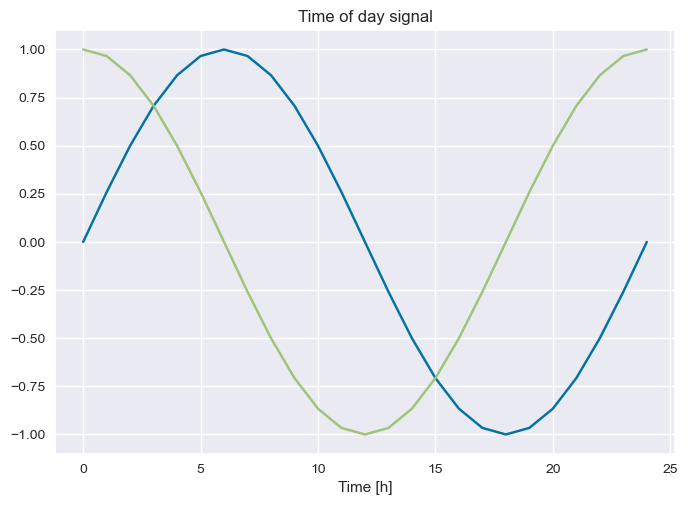

In [ ]:
timestamp_s = train_df.datetime.map(pd.Timestamp.timestamp)

day = 24 * 60 * 60
year = 365.2425 * day

train_df['day_sin'] = np.sin(timestamp_s * (2 * np.pi / day))
train_df['day_cos'] = np.cos(timestamp_s * (2 * np.pi / day))
train_df['year_sin'] = np.sin(timestamp_s * (2 * np.pi / year))
train_df['year_cos'] = np.cos(timestamp_s * (2 * np.pi / year))

plt.plot(np.array(train_df['day_sin'])[:25])
plt.plot(np.array(train_df['day_cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [ ]:
X = train_df.drop([
    'rain_1h',
    # 'rain_1h_bool'
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 17) (273504,) (68376, 17) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9073294	total: 5.25ms	remaining: 5.24s
1:	learn: 0.8934509	total: 8.99ms	remaining: 4.49s
2:	learn: 0.8814002	total: 12.4ms	remaining: 4.12s
3:	learn: 0.8709886	total: 16ms	remaining: 3.98s
4:	learn: 0.8618592	total: 19.4ms	remaining: 3.86s
5:	learn: 0.8540575	total: 22.9ms	remaining: 3.79s
6:	learn: 0.8469737	total: 26.5ms	remaining: 3.75s
7:	learn: 0.8412464	total: 30.2ms	remaining: 3.75s
8:	learn: 0.8357975	total: 33.8ms	remaining: 3.72s
9:	learn: 0.8313051	total: 37.3ms	remaining: 3.69s
10:	learn: 0.8270986	total: 40.9ms	remaining: 3.68s
11:	learn: 0.8234700	total: 44.7ms	remaining: 3.68s
12:	learn: 0.8202869	total: 48.4ms	remaining: 3.67s
13:	learn: 0.8174462	total: 51.9ms	remaining: 3.65s
14:	learn: 0.8152299	total: 55.4ms	remaining: 3.64s
15:	learn: 0.8133017	total: 58.7ms	remaining: 3.61s
16:	learn: 0.8113129	total: 62.3ms	remaining: 3.6s
17:	learn: 0.8096638	total: 65.7ms	remaining: 3.58s
18:	learn: 0.8083112	total: 69.2ms	remaining: 3

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8717642750416871


### Holiday, Season, etc

In [ ]:
def create_features(df):
    # Temperature Range
    df['temp_range'] = df['max_temp'] - df['min_temp']

    # # Weekend Indicator
    # df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    # Daytime Indicator
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)

    # # Season Indicator
    # def get_season(month):
    #     if month in [12, 1, 2]:
    #         return 'Winter'
    #     elif month in [3, 4, 5]:
    #         return 'Spring'
    #     elif month in [6, 7, 8]:
    #         return 'Summer'
    #     else:
    #         return 'Fall'
    #
    # df['season'] = df['month'].apply(get_season)
    #
    # # Encode 'season' column as one-hot encoding
    # season_encoded = pd.get_dummies(df['season'], prefix='season')
    #
    # # Concatenate the one-hot encoded columns with the original DataFrame
    # df_encoded = pd.concat([df, season_encoded], axis=1)

    # # Drop the original 'season' column
    # df_encoded.drop('season', axis=1, inplace=True)

    return df


# Usage:
# Assuming you have a DataFrame called train_df
train_df = create_features(train_df)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_min,6h_temp_max,6h_hum_mean,6h_hum_min,6h_hum_max,6h_clouds_mean,6h_clouds_min,6h_clouds_max,wind_x,wind_y,temp_diff_inv,d_point_diff_inv,hum_diff_inv,wind_spd_diff_inv
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0,0.00,0.00,24.750,24.75,24.75,95.0,95.0,95.0,100.000000,100.0,100.0,0.628156,-0.527086,0.17,0.16,0.0,-0.14
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0,-0.16,0.14,24.665,24.58,24.75,95.0,95.0,95.0,100.000000,100.0,100.0,0.890097,-0.359622,-2.02,-0.33,9.0,-0.26
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0,0.33,0.26,25.310,24.58,26.60,92.0,86.0,95.0,99.666667,99.0,100.0,1.138968,-0.437209,-0.71,-0.31,2.0,0.14
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0,0.31,-0.14,25.810,24.58,27.31,90.0,84.0,95.0,98.250000,94.0,100.0,1.027141,-0.333738,-0.10,-0.68,-3.0,0.22
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0,0.68,-0.22,26.130,24.58,27.41,89.4,84.0,95.0,98.600000,94.0,100.0,0.785649,-0.349794,-0.67,0.13,4.0,0.02


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 22) (273504,) (68376, 22) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9072573	total: 4.2ms	remaining: 4.2s
1:	learn: 0.8935115	total: 8.9ms	remaining: 4.44s
2:	learn: 0.8814821	total: 13.5ms	remaining: 4.47s
3:	learn: 0.8710593	total: 18.4ms	remaining: 4.58s
4:	learn: 0.8616953	total: 23.5ms	remaining: 4.67s
5:	learn: 0.8537313	total: 27.6ms	remaining: 4.58s
6:	learn: 0.8466257	total: 31.6ms	remaining: 4.48s
7:	learn: 0.8406650	total: 41.7ms	remaining: 5.17s
8:	learn: 0.8354921	total: 46.5ms	remaining: 5.12s
9:	learn: 0.8305931	total: 51.2ms	remaining: 5.06s
10:	learn: 0.8262037	total: 56.3ms	remaining: 5.06s
11:	learn: 0.8227522	total: 61.2ms	remaining: 5.04s
12:	learn: 0.8193572	total: 66.6ms	remaining: 5.06s
13:	learn: 0.8165155	total: 71.2ms	remaining: 5.02s
14:	learn: 0.8139492	total: 76ms	remaining: 4.99s
15:	learn: 0.8117875	total: 80.8ms	remaining: 4.97s
16:	learn: 0.8098256	total: 86.2ms	remaining: 4.98s
17:	learn: 0.8079503	total: 91ms	remaining: 4.97s
18:	learn: 0.8063447	total: 95.8ms	remaining: 4.95s

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8716871320075648


### Temp Diff Feature

In [ ]:
train_df["temp_diff"] = train_df["temp"].diff()
train_df["temp_diff"].fillna(0, inplace=True)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 20) (273504,) (68376, 20) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9038755	total: 5.38ms	remaining: 5.38s
1:	learn: 0.8870117	total: 9.13ms	remaining: 4.56s
2:	learn: 0.8725131	total: 12.7ms	remaining: 4.21s
3:	learn: 0.8598855	total: 16.6ms	remaining: 4.12s
4:	learn: 0.8488541	total: 20.9ms	remaining: 4.16s
5:	learn: 0.8388716	total: 24.7ms	remaining: 4.1s
6:	learn: 0.8302383	total: 28.3ms	remaining: 4.02s
7:	learn: 0.8227712	total: 31.8ms	remaining: 3.95s
8:	learn: 0.8163343	total: 35.5ms	remaining: 3.91s
9:	learn: 0.8104689	total: 39.1ms	remaining: 3.87s
10:	learn: 0.8054658	total: 42.6ms	remaining: 3.83s
11:	learn: 0.8011032	total: 46.2ms	remaining: 3.81s
12:	learn: 0.7972864	total: 49.8ms	remaining: 3.78s
13:	learn: 0.7938406	total: 53.6ms	remaining: 3.77s
14:	learn: 0.7905656	total: 57.2ms	remaining: 3.76s
15:	learn: 0.7877109	total: 61ms	remaining: 3.75s
16:	learn: 0.7851998	total: 64.8ms	remaining: 3.75s
17:	learn: 0.7829540	total: 68.6ms	remaining: 3.74s
18:	learn: 0.7809482	total: 72.4ms	remaining: 3

171:	learn: 0.7402471	total: 664ms	remaining: 3.2s
172:	learn: 0.7401893	total: 669ms	remaining: 3.2s
173:	learn: 0.7401485	total: 673ms	remaining: 3.19s
174:	learn: 0.7400959	total: 678ms	remaining: 3.19s
175:	learn: 0.7399996	total: 682ms	remaining: 3.19s
176:	learn: 0.7399005	total: 685ms	remaining: 3.19s
177:	learn: 0.7398444	total: 690ms	remaining: 3.18s
178:	learn: 0.7397587	total: 693ms	remaining: 3.18s
179:	learn: 0.7396959	total: 698ms	remaining: 3.18s
180:	learn: 0.7395968	total: 702ms	remaining: 3.17s
181:	learn: 0.7395240	total: 705ms	remaining: 3.17s
182:	learn: 0.7391141	total: 709ms	remaining: 3.17s
183:	learn: 0.7390255	total: 713ms	remaining: 3.16s
184:	learn: 0.7389534	total: 716ms	remaining: 3.15s
185:	learn: 0.7388636	total: 720ms	remaining: 3.15s
186:	learn: 0.7388045	total: 724ms	remaining: 3.15s
187:	learn: 0.7387418	total: 727ms	remaining: 3.14s
188:	learn: 0.7386809	total: 731ms	remaining: 3.13s
189:	learn: 0.7385966	total: 735ms	remaining: 3.13s
190:	learn: 0.

331:	learn: 0.7286285	total: 1.29s	remaining: 2.59s
332:	learn: 0.7285685	total: 1.29s	remaining: 2.59s
333:	learn: 0.7285142	total: 1.29s	remaining: 2.58s
334:	learn: 0.7284665	total: 1.3s	remaining: 2.58s
335:	learn: 0.7284167	total: 1.3s	remaining: 2.58s
336:	learn: 0.7283902	total: 1.31s	remaining: 2.57s
337:	learn: 0.7283373	total: 1.31s	remaining: 2.57s
338:	learn: 0.7282795	total: 1.31s	remaining: 2.56s
339:	learn: 0.7282142	total: 1.32s	remaining: 2.56s
340:	learn: 0.7281755	total: 1.32s	remaining: 2.56s
341:	learn: 0.7281624	total: 1.32s	remaining: 2.55s
342:	learn: 0.7281218	total: 1.33s	remaining: 2.55s
343:	learn: 0.7280919	total: 1.33s	remaining: 2.54s
344:	learn: 0.7280358	total: 1.34s	remaining: 2.54s
345:	learn: 0.7280015	total: 1.34s	remaining: 2.54s
346:	learn: 0.7279522	total: 1.35s	remaining: 2.53s
347:	learn: 0.7278789	total: 1.35s	remaining: 2.53s
348:	learn: 0.7278014	total: 1.35s	remaining: 2.53s
349:	learn: 0.7277522	total: 1.36s	remaining: 2.52s
350:	learn: 0.

490:	learn: 0.7198005	total: 1.9s	remaining: 1.97s
491:	learn: 0.7197588	total: 1.9s	remaining: 1.96s
492:	learn: 0.7197115	total: 1.9s	remaining: 1.96s
493:	learn: 0.7196675	total: 1.91s	remaining: 1.95s
494:	learn: 0.7196234	total: 1.91s	remaining: 1.95s
495:	learn: 0.7195758	total: 1.92s	remaining: 1.95s
496:	learn: 0.7195462	total: 1.92s	remaining: 1.94s
497:	learn: 0.7195273	total: 1.92s	remaining: 1.94s
498:	learn: 0.7194738	total: 1.93s	remaining: 1.93s
499:	learn: 0.7194574	total: 1.93s	remaining: 1.93s
500:	learn: 0.7194129	total: 1.93s	remaining: 1.93s
501:	learn: 0.7193586	total: 1.94s	remaining: 1.92s
502:	learn: 0.7193125	total: 1.94s	remaining: 1.92s
503:	learn: 0.7192712	total: 1.95s	remaining: 1.92s
504:	learn: 0.7192346	total: 1.95s	remaining: 1.91s
505:	learn: 0.7191852	total: 1.95s	remaining: 1.91s
506:	learn: 0.7191505	total: 1.96s	remaining: 1.9s
507:	learn: 0.7191015	total: 1.96s	remaining: 1.9s
508:	learn: 0.7190426	total: 1.96s	remaining: 1.9s
509:	learn: 0.7189

652:	learn: 0.7122938	total: 2.51s	remaining: 1.33s
653:	learn: 0.7122317	total: 2.51s	remaining: 1.33s
654:	learn: 0.7121895	total: 2.52s	remaining: 1.32s
655:	learn: 0.7121428	total: 2.52s	remaining: 1.32s
656:	learn: 0.7120951	total: 2.53s	remaining: 1.32s
657:	learn: 0.7120628	total: 2.53s	remaining: 1.31s
658:	learn: 0.7120235	total: 2.53s	remaining: 1.31s
659:	learn: 0.7119702	total: 2.54s	remaining: 1.31s
660:	learn: 0.7119083	total: 2.54s	remaining: 1.3s
661:	learn: 0.7118563	total: 2.55s	remaining: 1.3s
662:	learn: 0.7118156	total: 2.55s	remaining: 1.3s
663:	learn: 0.7117508	total: 2.56s	remaining: 1.29s
664:	learn: 0.7116979	total: 2.56s	remaining: 1.29s
665:	learn: 0.7116744	total: 2.56s	remaining: 1.28s
666:	learn: 0.7116008	total: 2.57s	remaining: 1.28s
667:	learn: 0.7115577	total: 2.57s	remaining: 1.28s
668:	learn: 0.7115180	total: 2.58s	remaining: 1.27s
669:	learn: 0.7114801	total: 2.58s	remaining: 1.27s
670:	learn: 0.7114524	total: 2.58s	remaining: 1.27s
671:	learn: 0.7

852:	learn: 0.7041771	total: 3.31s	remaining: 571ms
853:	learn: 0.7041335	total: 3.32s	remaining: 567ms
854:	learn: 0.7040982	total: 3.32s	remaining: 564ms
855:	learn: 0.7040777	total: 3.33s	remaining: 560ms
856:	learn: 0.7040435	total: 3.33s	remaining: 556ms
857:	learn: 0.7040014	total: 3.33s	remaining: 552ms
858:	learn: 0.7039802	total: 3.34s	remaining: 548ms
859:	learn: 0.7039533	total: 3.34s	remaining: 544ms
860:	learn: 0.7039276	total: 3.35s	remaining: 540ms
861:	learn: 0.7038758	total: 3.35s	remaining: 536ms
862:	learn: 0.7038485	total: 3.35s	remaining: 532ms
863:	learn: 0.7038192	total: 3.36s	remaining: 528ms
864:	learn: 0.7037695	total: 3.36s	remaining: 524ms
865:	learn: 0.7036769	total: 3.36s	remaining: 521ms
866:	learn: 0.7036592	total: 3.37s	remaining: 517ms
867:	learn: 0.7036185	total: 3.37s	remaining: 513ms
868:	learn: 0.7035729	total: 3.37s	remaining: 509ms
869:	learn: 0.7035541	total: 3.38s	remaining: 505ms
870:	learn: 0.7035163	total: 3.38s	remaining: 501ms
871:	learn: 

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8340918525292336


### Presure Diff Feature

In [ ]:
train_df["prssr_diff"] = train_df["prssr"].diff()
train_df["prssr_diff"].fillna(0, inplace=True)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 21) (273504,) (68376, 21) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9038755	total: 4.96ms	remaining: 4.95s
1:	learn: 0.8870117	total: 8.7ms	remaining: 4.34s
2:	learn: 0.8725131	total: 13.3ms	remaining: 4.42s
3:	learn: 0.8598855	total: 17.1ms	remaining: 4.26s
4:	learn: 0.8488541	total: 21ms	remaining: 4.17s
5:	learn: 0.8388716	total: 24.8ms	remaining: 4.1s
6:	learn: 0.8302383	total: 28.5ms	remaining: 4.05s
7:	learn: 0.8227712	total: 32.3ms	remaining: 4.01s
8:	learn: 0.8163343	total: 36.2ms	remaining: 3.98s
9:	learn: 0.8104689	total: 40ms	remaining: 3.96s
10:	learn: 0.8054658	total: 43.7ms	remaining: 3.92s
11:	learn: 0.8011032	total: 47.4ms	remaining: 3.9s
12:	learn: 0.7972864	total: 51.2ms	remaining: 3.89s
13:	learn: 0.7938406	total: 55ms	remaining: 3.87s
14:	learn: 0.7905656	total: 58.7ms	remaining: 3.85s
15:	learn: 0.7876542	total: 62.4ms	remaining: 3.84s
16:	learn: 0.7851378	total: 66.2ms	remaining: 3.83s
17:	learn: 0.7828797	total: 70.8ms	remaining: 3.86s
18:	learn: 0.7808600	total: 90.4ms	remaining: 4.67s
1

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8282517784111452


### Dpoint Diff Feature

In [ ]:
train_df["d_point_diff"] = train_df["d_point"].diff()
train_df["d_point_diff"].fillna(0, inplace=True)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0,0.00
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0,-0.16
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0,0.33
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0,0.31
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0,0.68


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 23) (273504,) (68376, 23) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034390	total: 5.79ms	remaining: 5.78s
1:	learn: 0.8863861	total: 10ms	remaining: 5s
2:	learn: 0.8715277	total: 14.2ms	remaining: 4.73s
3:	learn: 0.8587348	total: 18.9ms	remaining: 4.71s
4:	learn: 0.8470897	total: 23.6ms	remaining: 4.69s
5:	learn: 0.8370863	total: 27.8ms	remaining: 4.6s
6:	learn: 0.8282637	total: 31.6ms	remaining: 4.49s
7:	learn: 0.8208022	total: 35.9ms	remaining: 4.45s
8:	learn: 0.8141044	total: 40ms	remaining: 4.4s
9:	learn: 0.8083057	total: 43.8ms	remaining: 4.34s
10:	learn: 0.8030241	total: 47.8ms	remaining: 4.29s
11:	learn: 0.7983538	total: 51.7ms	remaining: 4.26s
12:	learn: 0.7943835	total: 55.6ms	remaining: 4.22s
13:	learn: 0.7909066	total: 59.4ms	remaining: 4.18s
14:	learn: 0.7875440	total: 63.4ms	remaining: 4.17s
15:	learn: 0.7845079	total: 67.3ms	remaining: 4.14s
16:	learn: 0.7819590	total: 71ms	remaining: 4.11s
17:	learn: 0.7796677	total: 74.9ms	remaining: 4.08s
18:	learn: 0.7775660	total: 79.1ms	remaining: 4.08s
19:

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8182098601417697


### Wind SPD Diff Feature

In [ ]:
train_df["wind_spd_diff"] = train_df["wind_spd"].diff()
train_df["wind_spd_diff"].fillna(0, inplace=True)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff,wind_spd_diff
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0,0.00,0.00
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0,-0.16,0.14
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0,0.33,0.26
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0,0.31,-0.14
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0,0.68,-0.22


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 23) (273504,) (68376, 23) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034390	total: 5.26ms	remaining: 5.25s
100:	learn: 0.7364632	total: 559ms	remaining: 4.97s
200:	learn: 0.7221217	total: 950ms	remaining: 3.78s
300:	learn: 0.7138849	total: 1.32s	remaining: 3.06s
400:	learn: 0.7067911	total: 1.69s	remaining: 2.52s
500:	learn: 0.7010814	total: 2.07s	remaining: 2.06s
600:	learn: 0.6961571	total: 2.43s	remaining: 1.61s
700:	learn: 0.6911846	total: 2.82s	remaining: 1.2s
800:	learn: 0.6867718	total: 3.19s	remaining: 792ms
900:	learn: 0.6827111	total: 3.56s	remaining: 391ms
999:	learn: 0.6784838	total: 3.94s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8143473136957506


In [ ]:
train_df.to_csv(f"{DATA_DIR}/train_ready.csv", index=False)

### Rolling Stats Feature

In [ ]:
# Define a time window (e.g., 6 hours) for rolling statistics
time_window = 6

# Calculate rolling mean, min, and max for temperature within the time window
train_df['6h_temp_mean'] = train_df['temp'].rolling(time_window, min_periods=1).mean()
train_df['6h_temp_min'] = train_df['temp'].rolling(time_window, min_periods=1).min()
train_df['6h_temp_max'] = train_df['temp'].rolling(time_window, min_periods=1).max()

# hum
train_df['6h_hum_mean'] = train_df['hum'].rolling(time_window, min_periods=1).mean()
train_df['6h_hum_min'] = train_df['hum'].rolling(time_window, min_periods=1).min()
train_df['6h_hum_max'] = train_df['hum'].rolling(time_window, min_periods=1).max()

# cloud
train_df['6h_clouds_mean'] = train_df['clouds'].rolling(time_window, min_periods=1).mean()
train_df['6h_clouds_min'] = train_df['clouds'].rolling(time_window, min_periods=1).min()
train_df['6h_clouds_max'] = train_df['clouds'].rolling(time_window, min_periods=1).max()

train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_min,6h_temp_max,6h_hum_mean,6h_hum_min,6h_hum_max,6h_clouds_mean,6h_clouds_min,6h_clouds_max
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0,0.00,0.00,24.750,24.75,24.75,95.0,95.0,95.0,100.000000,100.0,100.0
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0,-0.16,0.14,24.665,24.58,24.75,95.0,95.0,95.0,100.000000,100.0,100.0
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0,0.33,0.26,25.310,24.58,26.60,92.0,86.0,95.0,99.666667,99.0,100.0
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0,0.31,-0.14,25.810,24.58,27.31,90.0,84.0,95.0,98.250000,94.0,100.0
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0,0.68,-0.22,26.130,24.58,27.41,89.4,84.0,95.0,98.600000,94.0,100.0


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
    # 'clouds'
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 32) (273504,) (68376, 32) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034390	total: 6.2ms	remaining: 6.19s
100:	learn: 0.7360366	total: 491ms	remaining: 4.37s
200:	learn: 0.7204587	total: 998ms	remaining: 3.97s
300:	learn: 0.7110090	total: 1.53s	remaining: 3.55s
400:	learn: 0.7032520	total: 1.94s	remaining: 2.89s
500:	learn: 0.6971091	total: 2.43s	remaining: 2.42s
600:	learn: 0.6918350	total: 3.13s	remaining: 2.08s
700:	learn: 0.6864585	total: 3.54s	remaining: 1.51s
800:	learn: 0.6816646	total: 3.96s	remaining: 985ms
900:	learn: 0.6771842	total: 4.35s	remaining: 478ms
999:	learn: 0.6728030	total: 4.75s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8094742034876095


### Wind Vector Feature

Text(0, 0.5, 'Wind Velocity [m/s]')

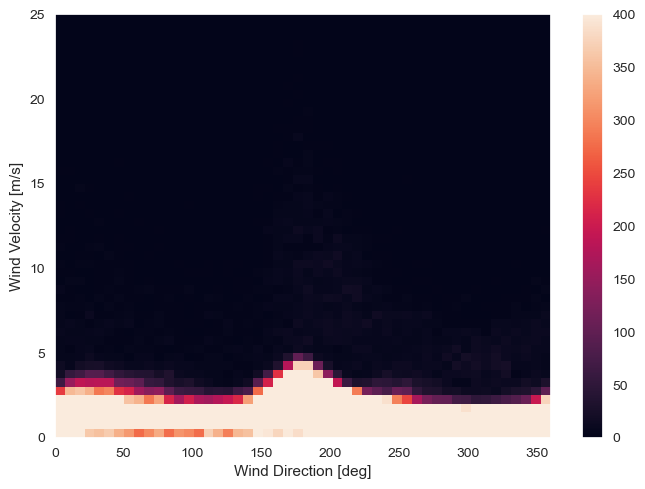

In [ ]:
plt.hist2d(train_df['wind_deg'], train_df['wind_spd'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

(-24.90486745229364,
 20.79086374542152,
 -16.047027500632506,
 16.677890424529835)

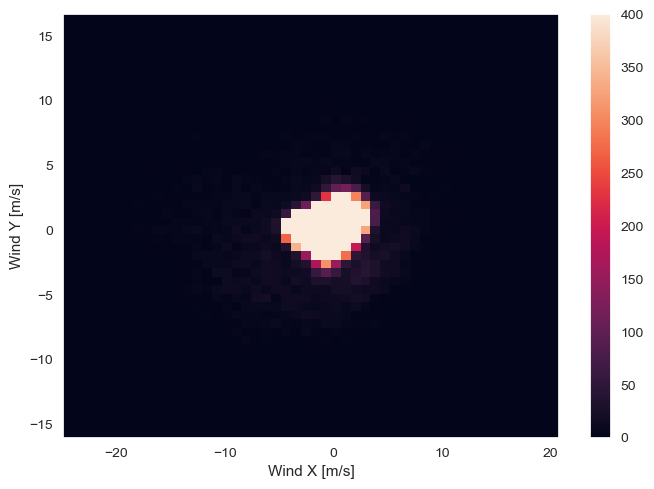

In [ ]:
# convert wind speed and deg to vector
train_df['wind_rad'] = np.radians(train_df['wind_deg'])

train_df['wind_x'] = train_df['wind_spd'] * np.cos(train_df['wind_rad'])
train_df['wind_y'] = train_df['wind_spd'] * np.sin(train_df['wind_rad'])
train_df.drop(['wind_rad'], axis=1, inplace=True)

# plot wind_x and wind_y heatmap
plt.hist2d(train_df['wind_x'], train_df['wind_y'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [ ]:
X = train_df.drop([
    'rain_1h',
    # 'rain_1h_bool'
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
    # 'wind_deg',
    # 'wind_spd',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 34) (273504,) (68376, 34) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034390	total: 7.29ms	remaining: 7.28s
100:	learn: 0.7341910	total: 734ms	remaining: 6.53s
200:	learn: 0.7199946	total: 1.18s	remaining: 4.7s
300:	learn: 0.7100009	total: 1.57s	remaining: 3.65s
400:	learn: 0.7026150	total: 1.97s	remaining: 2.94s
500:	learn: 0.6962216	total: 2.38s	remaining: 2.37s
600:	learn: 0.6901798	total: 2.76s	remaining: 1.83s
700:	learn: 0.6847350	total: 3.16s	remaining: 1.35s
800:	learn: 0.6798318	total: 3.55s	remaining: 882ms
900:	learn: 0.6753430	total: 3.93s	remaining: 432ms
999:	learn: 0.6709050	total: 4.32s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.80832189055681


### Inverse Diff Feature

In [ ]:
train_df = train_df.iloc[::-1]

# temp
train_df["temp_diff_inv"] = train_df["temp"].diff()
train_df["temp_diff_inv"].fillna(0, inplace=True)

# d_point
train_df["d_point_diff_inv"] = train_df["d_point"].diff()
train_df["d_point_diff_inv"].fillna(0, inplace=True)

# hum
train_df["hum_diff_inv"] = train_df["hum"].diff()
train_df["hum_diff_inv"].fillna(0, inplace=True)

# wind_spd
train_df["wind_spd_diff_inv"] = train_df["wind_spd"].diff()
train_df["wind_spd_diff_inv"].fillna(0, inplace=True)

train_df = train_df.iloc[::-1]
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_min,6h_temp_max,6h_hum_mean,6h_hum_min,6h_hum_max,6h_clouds_mean,6h_clouds_min,6h_clouds_max,wind_x,wind_y,temp_diff_inv,d_point_diff_inv,hum_diff_inv,wind_spd_diff_inv
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0,0.00,0.00,24.750,24.75,24.75,95.0,95.0,95.0,100.000000,100.0,100.0,0.628156,-0.527086,0.17,0.16,0.0,-0.14
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0,-0.16,0.14,24.665,24.58,24.75,95.0,95.0,95.0,100.000000,100.0,100.0,0.890097,-0.359622,-2.02,-0.33,9.0,-0.26
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0,0.33,0.26,25.310,24.58,26.60,92.0,86.0,95.0,99.666667,99.0,100.0,1.138968,-0.437209,-0.71,-0.31,2.0,0.14
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0,0.31,-0.14,25.810,24.58,27.31,90.0,84.0,95.0,98.250000,94.0,100.0,1.027141,-0.333738,-0.10,-0.68,-3.0,0.22
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0,0.68,-0.22,26.130,24.58,27.41,89.4,84.0,95.0,98.600000,94.0,100.0,0.785649,-0.349794,-0.67,0.13,4.0,0.02


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
    # 'clouds'
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 38) (273504,) (68376, 38) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034241	total: 4.53ms	remaining: 4.52s
100:	learn: 0.7230423	total: 563ms	remaining: 5.01s
200:	learn: 0.7062604	total: 1.33s	remaining: 5.3s
300:	learn: 0.6954061	total: 1.76s	remaining: 4.08s
400:	learn: 0.6861271	total: 2.21s	remaining: 3.3s
500:	learn: 0.6791438	total: 2.69s	remaining: 2.68s
600:	learn: 0.6732251	total: 3.31s	remaining: 2.2s
700:	learn: 0.6672843	total: 3.73s	remaining: 1.59s
800:	learn: 0.6621017	total: 4.15s	remaining: 1.03s
900:	learn: 0.6575733	total: 4.59s	remaining: 504ms
999:	learn: 0.6526987	total: 4.99s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7897652863813558


### Try new feat

In [ ]:
backup_train_df = train_df.copy()

In [ ]:
train_df = backup_train_df.copy()
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_min,6h_temp_max,6h_hum_mean,6h_hum_min,6h_hum_max,6h_clouds_mean,6h_clouds_min,6h_clouds_max,wind_x,wind_y,temp_diff_inv,d_point_diff_inv,hum_diff_inv,wind_spd_diff_inv
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,100.0,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0.00,0.0,0.00,0.00,24.750,24.75,24.75,95.0,95.0,95.0,100.000000,100.0,100.0,0.628156,-0.527086,0.17,0.16,0.0,-0.14
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,100.0,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,-0.17,0.0,-0.16,0.14,24.665,24.58,24.75,95.0,95.0,95.0,100.000000,100.0,100.0,0.890097,-0.359622,-2.02,-0.33,9.0,-0.26
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,99.0,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,2.02,0.0,0.33,0.26,25.310,24.58,26.60,92.0,86.0,95.0,99.666667,99.0,100.0,1.138968,-0.437209,-0.71,-0.31,2.0,0.14
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,94.0,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0.71,0.0,0.31,-0.14,25.810,24.58,27.31,90.0,84.0,95.0,98.250000,94.0,100.0,1.027141,-0.333738,-0.10,-0.68,-3.0,0.22
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,100.0,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0.10,-1.0,0.68,-0.22,26.130,24.58,27.41,89.4,84.0,95.0,98.600000,94.0,100.0,0.785649,-0.349794,-0.67,0.13,4.0,0.02


In [ ]:
from sklearn.feature_selection import mutual_info_regression as mir

# Display mutual information score
pd.DataFrame(
    mir(train_df.drop(['datetime', 'rain_1h'], axis=1), train_df.rain_1h),
    index=train_df.drop(['datetime', 'rain_1h'], axis=1).columns,
    columns=['MI score']
).sort_values(by='MI score', ascending=False)

,MI score
hour,0.106314
day_sin,0.094427
hum,0.051759
temp,0.047845
min_temp,0.045574
max_temp,0.045060
feels,0.043000
day_cos,0.034833
clouds,0.034199
6h_clouds_min,0.031647


In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
    'year_cos',
    'year_sin',
    'dayofweek'
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 35) (273504,) (68376, 35) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034241	total: 8.69ms	remaining: 8.68s
100:	learn: 0.7234403	total: 510ms	remaining: 4.54s
200:	learn: 0.7076252	total: 991ms	remaining: 3.94s
300:	learn: 0.6976508	total: 1.57s	remaining: 3.65s
400:	learn: 0.6898138	total: 1.97s	remaining: 2.94s
500:	learn: 0.6833201	total: 2.42s	remaining: 2.41s
600:	learn: 0.6774064	total: 2.9s	remaining: 1.93s
700:	learn: 0.6721671	total: 3.38s	remaining: 1.44s
800:	learn: 0.6674847	total: 3.86s	remaining: 959ms
900:	learn: 0.6630686	total: 4.35s	remaining: 479ms
999:	learn: 0.6588497	total: 4.75s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7893254969759362


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8080869694346355


In [ ]:
xgb_model = xgb.XGBRegressor(
    learning_rate=0.1,
    max_depth=8,
    min_child_weight=11,
    n_estimators=100,
    n_jobs=1,
    objective="reg:squarederror",
    subsample=0.7000000000000001,
    verbosity=0,
    random_state=42,
    device="cuda"
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=11, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=1,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_val_pred = xgb_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7932130138394483


### Random Validation

In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

# n = len(train_df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, y_train = X[0:int(n*0.8)], y[0:int(n*0.8)]
# X_test, y_test = X[int(n*0.8):], y[int(n*0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 38) (273504,) (68376, 38) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9200294	total: 14.4ms	remaining: 14.3s
100:	learn: 0.7400003	total: 568ms	remaining: 5.05s
200:	learn: 0.7240828	total: 1.18s	remaining: 4.69s
300:	learn: 0.7139021	total: 1.6s	remaining: 3.71s
400:	learn: 0.7060138	total: 2.01s	remaining: 3s
500:	learn: 0.6985325	total: 2.43s	remaining: 2.42s
600:	learn: 0.6926672	total: 2.83s	remaining: 1.88s
700:	learn: 0.6866924	total: 3.24s	remaining: 1.38s
800:	learn: 0.6814599	total: 3.65s	remaining: 907ms
900:	learn: 0.6766746	total: 4.07s	remaining: 447ms
999:	learn: 0.6720386	total: 4.47s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7184396492214972


In [ ]:
xgb_model = xgb.XGBRegressor(
    learning_rate=0.1,
    max_depth=8,
    min_child_weight=11,
    n_estimators=100,
    n_jobs=1,
    objective="reg:squarederror",
    subsample=0.7000000000000001,
    verbosity=0,
    random_state=42,
    device="cuda"
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=11, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=1,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_val_pred = xgb_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7468305190741963


## Feature Selection

### BORUTA

In [ ]:
X = train_df.drop([
    'rain_1h',
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(256472, 31) (256472,) (64118, 31) (64118,)


### Sequential Feature Selector

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

model = xgb.XGBRegressor(n_estimators=25, objective='reg:squarederror', random_state=42, device="cuda")

sfs = SFS(model,
          k_features=(1, X_train.shape[1]),  # Specify the range of feature subsets to consider
          forward=True,  # Use forward selection
          floating=False,  # Set to True for floating selection (backward elimination)
          verbose=2,  # Set verbosity level (0, 1, or 2)
          scoring='neg_mean_squared_error',  # Use an appropriate scoring metric
          n_jobs=4,
          cv=5)  # Number of cross-validation folds
sfs = sfs.fit(X_train, y_train)

selected_feature_indices = sfs.k_feature_idx_
print("Selected feature indices:", selected_feature_indices)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  31 out of  31 | elapsed:   25.2s finished

[2023-09-16 15:29:00] Features: 1/31 -- score: -0.7963896668246698[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  30 out of  30 | elapsed:   32.0s finished

[2023-09-16 15:29:32] Features: 2/31 -- score: -0.6892527741560851[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  29 out of  29 | elapsed:   37.6s finished

[2023-09-16 15:30:10] Features: 3/31 -- score: -0.6368353159272053[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  28 out of  28 | elapsed:   38.9s finished

[2023-09-16 15:30:49] Features: 4/31 -- score: -0.6157872746764858[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  27 out of  27 | elapsed:   49.4s finished

[2023-

[15:50:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.
[15:50:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.
[15:50:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.
[15:50:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.
[15:50:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.
Selected feature indices:

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.9s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.9s finished

[2023-09-16 15:50:23] Features: 31/31 -- score: -0.5820668212333822

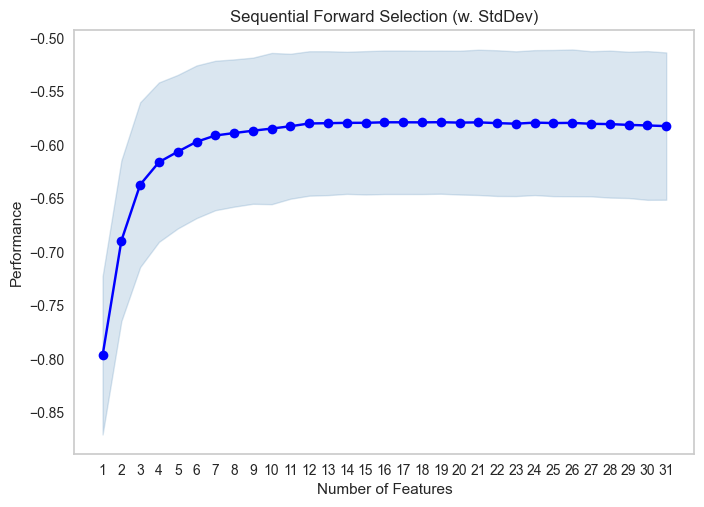

In [ ]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

In [ ]:
# Assuming you have selected_feature_indices as a list of feature indices
selected_feature_names = [X_train.columns[i] for i in selected_feature_indices]

In [ ]:
# Create a new DataFrame with selected features
X_train_selected = X_train[selected_feature_names]
X_test_selected = X_test[selected_feature_names]

In [ ]:
X_train_selected.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 256472 entries, 0 to 273643
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   hum            256472 non-null  float64
 1   wind_spd       256472 non-null  float64
 2   wind_deg       256472 non-null  float64
 3   clouds         256472 non-null  float64
 4   year           256472 non-null  int64  
 5   week           256472 non-null  int64  
 6   hour           256472 non-null  int64  
 7   dayofweek      256472 non-null  int64  
 8   day_sin        256472 non-null  float64
 9   temp_range     256472 non-null  float64
 10  is_weekend     256472 non-null  int32  
 11  is_daytime     256472 non-null  int32  
 12  season_Fall    256472 non-null  uint8  
 13  season_Spring  256472 non-null  uint8  
 14  season_Winter  256472 non-null  uint8  
 15  temp_diff      256472 non-null  float64
 16  prssr_diff     256472 non-null  float64
 17  d_point_diff   256472 non-nul

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 256472 entries, 0 to 273643
Data columns (total 31 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   temp           256472 non-null  float64
 1   d_point        256472 non-null  float64
 2   feels          256472 non-null  float64
 3   min_temp       256472 non-null  float64
 4   max_temp       256472 non-null  float64
 5   prssr          256472 non-null  float64
 6   hum            256472 non-null  float64
 7   wind_spd       256472 non-null  float64
 8   wind_deg       256472 non-null  float64
 9   clouds         256472 non-null  float64
 10  year           256472 non-null  int64  
 11  month          256472 non-null  int64  
 12  week           256472 non-null  int64  
 13  day            256472 non-null  int64  
 14  hour           256472 non-null  int64  
 15  dayofweek      256472 non-null  int64  
 16  day_sin        256472 non-null  float64
 17  day_cos        256472 non-nul

In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train_selected, y_train)

Learning rate set to 0.08354
0:	learn: 0.9290565	total: 4.56ms	remaining: 4.56s
1:	learn: 0.9116944	total: 8.31ms	remaining: 4.15s
2:	learn: 0.8966766	total: 11.8ms	remaining: 3.93s
3:	learn: 0.8837985	total: 15.2ms	remaining: 3.78s
4:	learn: 0.8723585	total: 18.7ms	remaining: 3.71s
5:	learn: 0.8619760	total: 22.4ms	remaining: 3.71s
6:	learn: 0.8528891	total: 26ms	remaining: 3.68s
7:	learn: 0.8449266	total: 29.5ms	remaining: 3.66s
8:	learn: 0.8383923	total: 32.9ms	remaining: 3.62s
9:	learn: 0.8323104	total: 36.3ms	remaining: 3.6s
10:	learn: 0.8269525	total: 39.9ms	remaining: 3.59s
11:	learn: 0.8223687	total: 43.3ms	remaining: 3.57s
12:	learn: 0.8180749	total: 46.8ms	remaining: 3.55s
13:	learn: 0.8144605	total: 50.2ms	remaining: 3.53s
14:	learn: 0.8110777	total: 53.9ms	remaining: 3.54s
15:	learn: 0.8081254	total: 57.4ms	remaining: 3.53s
16:	learn: 0.8055563	total: 61ms	remaining: 3.53s
17:	learn: 0.8033248	total: 64.6ms	remaining: 3.52s
18:	learn: 0.8009355	total: 68.2ms	remaining: 3.52

In [ ]:
y_val_pred = cbr_model.predict(X_test_selected)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8425843785193063


In [ ]:
X_train_selected = pd.concat([X_train_selected, X_train['clouds_type']], axis=1)
X_test_selected = pd.concat([X_test_selected, X_test['clouds_type']], axis=1)
X_train_selected.head()

In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', cat_features=["clouds_type"], random_state=42)
cbr_model.fit(X_train_selected, y_train)

In [ ]:
y_val_pred = cbr_model.predict(X_test_selected)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

In [ ]:
# normalize data
scaler = StandardScaler()
num_cols = X_train_selected.select_dtypes(include=np.number).columns.tolist()
num_cols = list(
    set(num_cols) - {'is_weekend', 'is_daytime', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter',
                     'clouds_type'})
X_train_selected[num_cols] = scaler.fit_transform(X_train_selected[num_cols])
X_test_selected[num_cols] = scaler.transform(X_test_selected[num_cols])

X_train_selected.head()

In [ ]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', cat_features=["clouds_type"], random_state=42)
cbr_model.fit(X_train_selected, y_train)

In [ ]:
y_val_pred = cbr_model.predict(X_test_selected)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

### CatBoost Select features

In [ ]:
from catboost import Pool, EShapCalcType, EFeaturesSelectionAlgorithm

feat_names = [col for col in X_train.columns.values]
train_pool = Pool(X_train, y_train, feature_names=feat_names)
test_pool = Pool(X_test, y_test, feature_names=feat_names)

cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
summary = cbr_model.select_features(
    train_pool,
    eval_set=test_pool,
    features_for_select='0-22',
    num_features_to_select=10,
    steps=3,
    algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
    shap_calc_type=EShapCalcType.Regular,
    train_final_model=True,
    logging_level='Silent',
    plot=True
)

In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8230237173118855


In [ ]:
X = train_df.drop([
    'rain_1h',
    'd_point',
    'dayofweek',
    'prssr',
    'year_cos'
], axis=1)
y = train_df['rain_1h']

X.drop([
    'datetime',
], axis=1, inplace=True)

n = len(train_df)
X_train, y_train = X[0:int(n * 0.8)], y[0:int(n * 0.8)]
X_test, y_test = X[int(n * 0.8):], y[int(n * 0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 19) (273504,) (68376, 19) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9034390	total: 4.34ms	remaining: 4.33s
100:	learn: 0.7376806	total: 380ms	remaining: 3.38s
200:	learn: 0.7251710	total: 798ms	remaining: 3.17s
300:	learn: 0.7175465	total: 1.25s	remaining: 2.92s
400:	learn: 0.7116804	total: 1.75s	remaining: 2.62s
500:	learn: 0.7063840	total: 2.25s	remaining: 2.24s
600:	learn: 0.7012138	total: 2.67s	remaining: 1.77s
700:	learn: 0.6958982	total: 3.04s	remaining: 1.3s
800:	learn: 0.6918978	total: 3.42s	remaining: 851ms
900:	learn: 0.6879956	total: 3.79s	remaining: 416ms
999:	learn: 0.6843386	total: 4.16s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8148631113172247


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, y_train = X[0:int(n*0.8)], y[0:int(n*0.8)]
# X_test, y_test = X[int(n*0.8):], y[int(n*0.8):]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 19) (273504,) (68376, 19) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9200793	total: 4.29ms	remaining: 4.28s
100:	learn: 0.7558111	total: 439ms	remaining: 3.91s
200:	learn: 0.7440581	total: 881ms	remaining: 3.5s
300:	learn: 0.7364357	total: 1.31s	remaining: 3.05s
400:	learn: 0.7305077	total: 1.8s	remaining: 2.69s
500:	learn: 0.7248417	total: 2.25s	remaining: 2.24s
600:	learn: 0.7198794	total: 2.69s	remaining: 1.78s
700:	learn: 0.7152618	total: 3.12s	remaining: 1.33s
800:	learn: 0.7110437	total: 3.56s	remaining: 885ms
900:	learn: 0.7072038	total: 3.93s	remaining: 432ms
999:	learn: 0.7036406	total: 4.3s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7444973564574504


### Manual

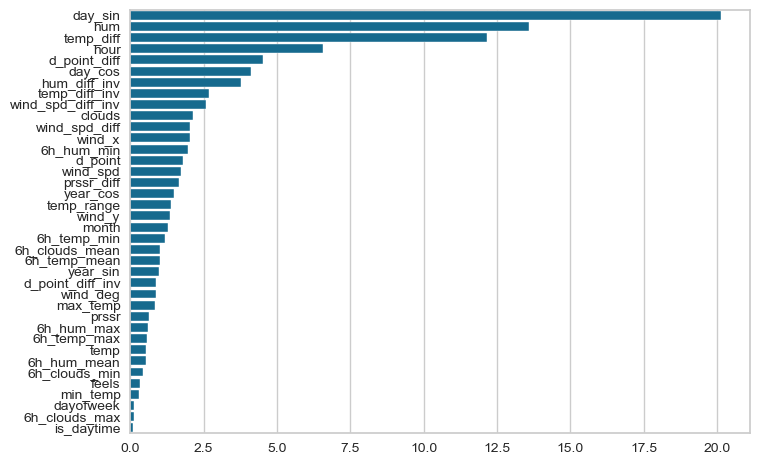

In [ ]:
feat_importances = pd.Series(cbr_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feat_importances, y=feat_importances.index, color="b")
plt.show()

Trying 1 features
RMSE: 0.8858397269313075
Trying 2 features
RMSE: 0.8295293864595544
Trying 3 features
RMSE: 0.8087266675754405
Trying 4 features
RMSE: 0.7931406259663589
Trying 5 features
RMSE: 0.7773334123506037
Trying 6 features
RMSE: 0.7771202975089332
Trying 7 features
RMSE: 0.7611754724352927
Trying 8 features
RMSE: 0.758036173805665
Trying 9 features
RMSE: 0.7524203534324453
Trying 10 features
RMSE: 0.7470648202824488
Trying 11 features
RMSE: 0.7442496637574012
Trying 12 features
RMSE: 0.7406963060360452
Trying 13 features
RMSE: 0.7378777434812831
Trying 14 features
RMSE: 0.7364173961176438
Trying 15 features
RMSE: 0.7351795207901091
Trying 16 features
RMSE: 0.7311897614471061
Trying 17 features
RMSE: 0.7308483343219159
Trying 18 features
RMSE: 0.7294124449889526
Trying 19 features
RMSE: 0.7277049577071979
Trying 20 features
RMSE: 0.7251957931579536
Trying 21 features
RMSE: 0.7256338666665592
Trying 22 features
RMSE: 0.724346829536752
Trying 23 features
RMSE: 0.723844796489345


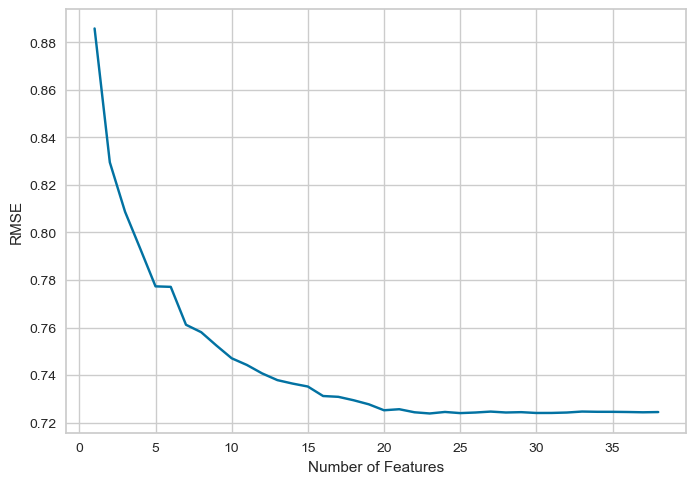

In [ ]:
cv_scores = []
for i in range(1, len(X_train.columns) + 1):
    print(f"Trying {i} features")
    selected_features = feat_importances[:i].index.tolist()
    X_selected = X[selected_features]
    cbr_model_cv = cb.CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        task_type='GPU',
        devices='0',
        verbose=0
    )
    score = np.sqrt(-cross_val_score(cbr_model_cv, X_selected, y, scoring="neg_mean_squared_error", cv=5))
    cv_scores.append(score.mean())
    print(f"RMSE: {score.mean()}")

plt.plot(range(1, len(X_train.columns) + 1), cv_scores)
plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.show()

In [ ]:
cbr_model_cv = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=0
)
np.sqrt(-cross_val_score(cbr_model_cv, X, y, scoring="neg_mean_squared_error", cv=5)).mean()

0.7245434845382424

In [ ]:
remove_feats = []
for idx, score in enumerate(cv_scores):
    if idx > 0 and score > cv_scores[idx-1]:
        remove_feats.append(idx)

feat_importances.index[remove_feats].tolist()

['6h_temp_min',
 'year_sin',
 'wind_deg',
 'max_temp',
 '6h_hum_max',
 'temp',
 '6h_hum_mean',
 '6h_clouds_min',
 'is_daytime']

In [ ]:
X.drop(feat_importances.index[remove_feats].tolist(), axis=1, inplace=True)
X.head()

,d_point,feels,min_temp,prssr,hum,wind_spd,clouds,month,hour,dayofweek,day_sin,day_cos,year_cos,temp_range,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_max,6h_hum_min,6h_clouds_mean,6h_clouds_max,wind_x,wind_y,temp_diff_inv,d_point_diff_inv,hum_diff_inv,wind_spd_diff_inv
0,23.89,25.76,24.28,1012.0,95.0,0.82,100.0,1,0,0,-6.132363e-13,1.000000,0.999995,0.94,0.00,0.0,0.00,0.00,24.750,24.75,95.0,100.000000,100.0,0.628156,-0.527086,0.17,0.16,0.0,-0.14
1,23.73,25.57,23.99,1012.0,95.0,0.96,100.0,1,1,0,2.588190e-01,0.965926,0.999997,1.27,-0.17,0.0,-0.16,0.14,24.665,24.75,95.0,100.000000,100.0,0.890097,-0.359622,-2.02,-0.33,9.0,-0.26
2,24.06,26.60,26.10,1012.0,86.0,1.22,99.0,1,2,0,5.000000e-01,0.866025,0.999999,1.29,2.02,0.0,0.33,0.26,25.310,26.60,86.0,99.666667,100.0,1.138968,-0.437209,-0.71,-0.31,2.0,0.14
3,24.37,30.90,26.59,1012.0,84.0,1.08,94.0,1,3,0,7.071068e-01,0.707107,1.000000,1.77,0.71,0.0,0.31,-0.14,25.810,27.31,84.0,98.250000,100.0,1.027141,-0.333738,-0.10,-0.68,-3.0,0.22
4,25.05,31.54,26.58,1011.0,87.0,0.86,100.0,1,4,0,8.660254e-01,0.500000,1.000000,1.73,0.10,-1.0,0.68,-0.22,26.130,27.41,84.0,98.600000,100.0,0.785649,-0.349794,-0.67,0.13,4.0,0.02


In [ ]:
cbr_model_cv = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=0
)
np.sqrt(-cross_val_score(cbr_model_cv, X, y, scoring="neg_mean_squared_error", cv=5)).mean()

0.7244658446625081

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(273504, 29) (273504,) (68376, 29) (68376,)


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.084247
0:	learn: 0.9200294	total: 28.6ms	remaining: 28.6s
100:	learn: 0.7408815	total: 440ms	remaining: 3.91s
200:	learn: 0.7247993	total: 888ms	remaining: 3.53s
300:	learn: 0.7154288	total: 1.38s	remaining: 3.2s
400:	learn: 0.7080968	total: 1.81s	remaining: 2.7s
500:	learn: 0.7012273	total: 2.28s	remaining: 2.27s
600:	learn: 0.6951510	total: 2.78s	remaining: 1.85s
700:	learn: 0.6897277	total: 3.24s	remaining: 1.38s
800:	learn: 0.6847105	total: 3.75s	remaining: 931ms
900:	learn: 0.6798334	total: 4.2s	remaining: 462ms
999:	learn: 0.6747534	total: 4.7s	remaining: 0us


In [ ]:
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7191718099906296


In [ ]:
cbr_model = cb.CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    task_type='GPU',
    devices='0',
    verbose=100
)
cbr_model.fit(X, y)

Learning rate set to 0.086746
0:	learn: 0.9187865	total: 4.77ms	remaining: 4.76s
100:	learn: 0.7411427	total: 433ms	remaining: 3.85s
200:	learn: 0.7261278	total: 852ms	remaining: 3.39s
300:	learn: 0.7163764	total: 1.29s	remaining: 2.99s
400:	learn: 0.7088124	total: 1.78s	remaining: 2.67s
500:	learn: 0.7031263	total: 2.27s	remaining: 2.26s
600:	learn: 0.6976254	total: 2.9s	remaining: 1.92s
700:	learn: 0.6928856	total: 3.31s	remaining: 1.41s
800:	learn: 0.6884570	total: 3.78s	remaining: 939ms
900:	learn: 0.6840987	total: 4.31s	remaining: 474ms
999:	learn: 0.6802112	total: 4.82s	remaining: 0us


## Submission

In [ ]:
ori_test_df = pd.read_csv(f"{DATA_DIR}/test.csv")
test_df = ori_test_df.copy()
test_df = clean_cols(test_df, is_train=False)

In [ ]:
test_df.isnull().sum()

datetime    0
temp        0
d_point     1
feels       0
min_temp    0
max_temp    0
prssr       0
hum         0
wind_spd    0
wind_deg    0
clouds      0
dtype: int64

In [ ]:
test_df[test_df.d_point.isnull()]

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,clouds
48707,2023-07-23 11:00:00,-9998.49,NaN,-10005.49,-9998.97,-273.15,1010.0,0.0,2.41,170.0,97.0


In [ ]:
test_df["d_point"].fillna(method='bfill', inplace=True)

In [ ]:
test_df['month'] = test_df['datetime'].dt.month
test_df['hour'] = test_df['datetime'].dt.hour
test_df['dayofweek'] = test_df['datetime'].dt.dayofweek
timestamp_s = test_df.datetime.map(pd.Timestamp.timestamp)

day = 24 * 60 * 60
year = 365.2425 * day

test_df['day_sin'] = np.sin(timestamp_s * (2 * np.pi / day))
test_df['day_cos'] = np.cos(timestamp_s * (2 * np.pi / day))
test_df['year_sin'] = np.sin(timestamp_s * (2 * np.pi / year))
test_df['year_cos'] = np.cos(timestamp_s * (2 * np.pi / year))

In [ ]:
test_df = create_features(test_df)
test_df["temp_diff"] = test_df["temp"].diff()
test_df["temp_diff"].fillna(0, inplace=True)
test_df["prssr_diff"] = test_df["prssr"].diff()
test_df["prssr_diff"].fillna(0, inplace=True)
test_df["d_point_diff"] = test_df["d_point"].diff()
test_df["d_point_diff"].fillna(0, inplace=True)
test_df["wind_spd_diff"] = test_df["wind_spd"].diff()
test_df["wind_spd_diff"].fillna(0, inplace=True)

In [ ]:
# Define a time window (e.g., 6 hours) for rolling statistics
time_window = 6

# Calculate rolling mean, min, and max for temperature within the time window
test_df['6h_temp_mean'] = test_df['temp'].rolling(time_window, min_periods=1).mean()
test_df['6h_temp_min'] = test_df['temp'].rolling(time_window, min_periods=1).min()
test_df['6h_temp_max'] = test_df['temp'].rolling(time_window, min_periods=1).max()

# hum
test_df['6h_hum_mean'] = test_df['hum'].rolling(time_window, min_periods=1).mean()
test_df['6h_hum_min'] = test_df['hum'].rolling(time_window, min_periods=1).min()
test_df['6h_hum_max'] = test_df['hum'].rolling(time_window, min_periods=1).max()

# cloud
test_df['6h_clouds_mean'] = test_df['clouds'].rolling(time_window, min_periods=1).mean()
test_df['6h_clouds_min'] = test_df['clouds'].rolling(time_window, min_periods=1).min()
test_df['6h_clouds_max'] = test_df['clouds'].rolling(time_window, min_periods=1).max()

In [ ]:
test_df['wind_rad'] = np.radians(test_df['wind_deg'])

test_df['wind_x'] = test_df['wind_spd'] * np.cos(test_df['wind_rad'])
test_df['wind_y'] = test_df['wind_spd'] * np.sin(test_df['wind_rad'])
test_df.drop(['wind_rad'], axis=1, inplace=True)

In [ ]:
test_df = test_df.iloc[::-1]

# temp
test_df["temp_diff_inv"] = test_df["temp"].diff()
test_df["temp_diff_inv"].fillna(0, inplace=True)

# d_point
test_df["d_point_diff_inv"] = test_df["d_point"].diff()
test_df["d_point_diff_inv"].fillna(0, inplace=True)

# hum
test_df["hum_diff_inv"] = test_df["hum"].diff()
test_df["hum_diff_inv"].fillna(0, inplace=True)

# wind_spd
test_df["wind_spd_diff_inv"] = test_df["wind_spd"].diff()
test_df["wind_spd_diff_inv"].fillna(0, inplace=True)

test_df = test_df.iloc[::-1]

In [ ]:
test_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,clouds,month,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_daytime,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_min,6h_temp_max,6h_hum_mean,6h_hum_min,6h_hum_max,6h_clouds_mean,6h_clouds_min,6h_clouds_max,wind_x,wind_y,temp_diff_inv,d_point_diff_inv,hum_diff_inv,wind_spd_diff_inv
0,2018-01-01 00:00:00,26.59,23.66,26.59,26.02,27.16,1009.0,84.0,1.45,355.0,97.0,1,0,0,-2.389847e-12,1.000000,0.006193,0.999981,1.14,0,0.00,0.0,0.00,0.00,26.590,26.59,26.59,84.000000,84.0,84.0,97.00,97.0,97.0,1.444482,-0.126376,0.08,-1.26,-7.0,-0.22
1,2018-01-01 01:00:00,26.51,24.92,26.51,26.06,28.04,1009.0,91.0,1.67,351.0,95.0,1,1,0,2.588190e-01,0.965926,0.006910,0.999976,1.98,0,-0.08,0.0,1.26,0.22,26.550,26.51,26.59,87.500000,84.0,91.0,96.00,95.0,97.0,1.649440,-0.261246,-2.17,-0.79,7.0,-0.05
2,2018-01-01 02:00:00,28.68,25.71,34.68,28.03,29.30,1009.0,84.0,1.72,345.0,90.0,1,2,0,5.000000e-01,0.866025,0.007626,0.999971,1.27,0,2.17,0.0,0.79,0.05,27.260,26.51,28.68,86.333333,84.0,91.0,94.00,90.0,97.0,1.661392,-0.445169,-0.16,0.46,3.0,0.23
3,2018-01-01 03:00:00,28.84,25.25,34.51,28.52,29.08,1008.0,81.0,1.49,339.0,91.0,1,3,0,7.071068e-01,0.707107,0.008343,0.999965,0.56,0,0.16,-1.0,-0.46,-0.23,27.655,26.51,28.84,85.000000,81.0,91.0,93.25,90.0,97.0,1.391035,-0.533968,-0.91,0.63,7.0,0.10
4,2018-01-01 04:00:00,29.75,24.62,35.38,29.31,30.57,1007.0,74.0,1.39,339.0,96.0,1,4,0,8.660254e-01,0.500000,0.009060,0.999959,1.26,0,0.91,-1.0,-0.63,-0.10,28.074,26.51,29.75,82.800000,74.0,91.0,93.80,90.0,97.0,1.297677,-0.498131,-0.34,-2.26,-9.0,0.87


In [ ]:
selected_feature_names = X.columns.tolist()
selected_feature_names

['d_point',
 'feels',
 'min_temp',
 'prssr',
 'hum',
 'wind_spd',
 'clouds',
 'month',
 'hour',
 'dayofweek',
 'day_sin',
 'day_cos',
 'year_cos',
 'temp_range',
 'temp_diff',
 'prssr_diff',
 'd_point_diff',
 'wind_spd_diff',
 '6h_temp_mean',
 '6h_temp_max',
 '6h_hum_min',
 '6h_clouds_mean',
 '6h_clouds_max',
 'wind_x',
 'wind_y',
 'temp_diff_inv',
 'd_point_diff_inv',
 'hum_diff_inv',
 'wind_spd_diff_inv']

In [ ]:
test_df_selected = test_df[selected_feature_names]
test_df_selected.head()

,d_point,feels,min_temp,prssr,hum,wind_spd,clouds,month,hour,dayofweek,day_sin,day_cos,year_cos,temp_range,temp_diff,prssr_diff,d_point_diff,wind_spd_diff,6h_temp_mean,6h_temp_max,6h_hum_min,6h_clouds_mean,6h_clouds_max,wind_x,wind_y,temp_diff_inv,d_point_diff_inv,hum_diff_inv,wind_spd_diff_inv
0,23.66,26.59,26.02,1009.0,84.0,1.45,97.0,1,0,0,-2.389847e-12,1.000000,0.999981,1.14,0.00,0.0,0.00,0.00,26.590,26.59,84.0,97.00,97.0,1.444482,-0.126376,0.08,-1.26,-7.0,-0.22
1,24.92,26.51,26.06,1009.0,91.0,1.67,95.0,1,1,0,2.588190e-01,0.965926,0.999976,1.98,-0.08,0.0,1.26,0.22,26.550,26.59,84.0,96.00,97.0,1.649440,-0.261246,-2.17,-0.79,7.0,-0.05
2,25.71,34.68,28.03,1009.0,84.0,1.72,90.0,1,2,0,5.000000e-01,0.866025,0.999971,1.27,2.17,0.0,0.79,0.05,27.260,28.68,84.0,94.00,97.0,1.661392,-0.445169,-0.16,0.46,3.0,0.23
3,25.25,34.51,28.52,1008.0,81.0,1.49,91.0,1,3,0,7.071068e-01,0.707107,0.999965,0.56,0.16,-1.0,-0.46,-0.23,27.655,28.84,81.0,93.25,97.0,1.391035,-0.533968,-0.91,0.63,7.0,0.10
4,24.62,35.38,29.31,1007.0,74.0,1.39,96.0,1,4,0,8.660254e-01,0.500000,0.999959,1.26,0.91,-1.0,-0.63,-0.10,28.074,29.75,74.0,93.80,97.0,1.297677,-0.498131,-0.34,-2.26,-9.0,0.87


In [ ]:
test_df_selected = pd.concat([test_df_selected, test_df['clouds_type']], axis=1)

In [ ]:
X_train

In [ ]:
test_df.isnull().sum()

In [ ]:
X_train.shape

In [ ]:
X_train.head()

In [ ]:
test_df.head()

In [ ]:
test_df.shape

In [ ]:
# y_test_pred = cbr_model.predict(test_df.drop("datetime", axis=1))
y_test_pred = cbr_model.predict(test_df)
y_test_pred = [0 if x < 0 else x for x in y_test_pred]
y_test_pred[:10]

[0.5007965675835067,
 0.6450059800102963,
 0.09650833510751511,
 0.03307205585512918,
 0.41002395264017366,
 4.305837634482643,
 2.5203870670873556,
 1.992848142026915,
 1.3825131316809802,
 1.389443096608801]

In [ ]:
test_df

In [ ]:
submission_df = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

submission_df['datetime_iso'] = ori_test_df['datetime_iso']
submission_df['rain_1h'] = y_test_pred

# submission_df.loc[submission_df['rain_1h'] < 0, 'rain_1h'] = 0

# submission_df.to_csv(f"{SUBMISSION_DIR}/submission2.csv", index=False)
submission_df.to_csv(f"{SUBMISSION_DIR}/submission10.csv", index=False)

submission_df.head()

,datetime_iso,rain_1h
0,2018-01-01 00:00:00+00:00,0.500797
1,2018-01-01 01:00:00+00:00,0.645006
2,2018-01-01 02:00:00+00:00,0.096508
3,2018-01-01 03:00:00+00:00,0.033072
4,2018-01-01 04:00:00+00:00,0.410024


In [ ]:
submission_df.rain_1h.describe()

count    49368.000000
mean         0.340751
std          0.553055
min          0.000000
25%          0.035684
50%          0.153076
75%          0.392947
max          6.503082
Name: rain_1h, dtype: float64